# Baseline - TACO adaptado ao PT-BR (BERTimbau) multi-label, 27 emoções + neutral

Este notebook adapta o **TACO** (*A Triple-View Framework for Fine-Grained Emotion Classification
with Clustering-Guided Contrastive Learning*, Gong, Yang & Shen, ACL 2025) para o **mesmo cenário
do baseline BERTimbau** deste TCC e produz **exatamente as mesmas análises** para comparação direta.

## O que foi adaptado do TACO (e por quê)

O TACO original é **single-label** (27 emoções, sem `neutral`, `softmax` + `argmax`). Aqui mantemos
**28 rótulos (27 + neutral) e multi-label**, então cada visão foi generalizada:

| Visão do TACO | Original (single-label) | Adaptação multi-label deste notebook |
|---|---|---|
| **Instância–Rótulo** (CE) | `dual-encoder`; score `ŝ(u,e)=h_u·h_e`; `softmax`+CE | mesmo `dual-encoder`; os 28 scores `h_u·h_e` viram *logits*; **BCE `Class-Balanced`** (multi-label) no lugar da CE. A novidade sobre o baseline é que os *logits* vêm de **embeddings semânticos dos rótulos** (nome + descrição em PT-BR), não de uma camada linear "cega". |
| **Instância–Instância** (CCL) | `k-means`; positivo = *mesmo rótulo*, cluster diferente; negativo = *rótulo diferente*, mesmo cluster; InfoNCE | `k-means` igual; **positivo = conjunto de rótulos idêntico** e cluster diferente; **negativo = rótulos disjuntos** (sem rótulo em comum) e mesmo cluster. Pares de sobreposição parcial ficam de fora (escolha conservadora). |
| **Rótulo–Rótulo** (LDL) | confusabilidade via similaridade das colunas de predição; afasta rótulos confundíveis | **inalterado** — usa a matriz de scores `M∈R^{|B|×28}`; para multi-label usamos `sigmoid(M)` (colunas não-negativas → confusabilidade bem definida). |

Perda total: `L = L_BCE-CB + α·L_CCL + β·L_LDL` (Eq. 7 do artigo). Inferência: `sigmoid(h_u·h_e)`
seguida de limiar (0.5 e calibrado), idêntica ao baseline — nada de `argmax`.

Baseado no código oficial: https://github.com/Alcyoneus87/TACO

## Instalação

In [2]:
# !pip install transformers[torch] torch torchmetrics pandas numpy scikit-learn pyarrow sentencepiece protobuf scipy matplotlib

## Ambiente (Colab/Drive opcional)

In [3]:
USE_COLAB = False
USE_DRIVE = False

if USE_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

## Imports e configurações globais

In [4]:
import warnings
warnings.filterwarnings("ignore")

import io
import re
import gzip
import lzma
import json
import time
import math
import zipfile
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Optimizer

from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding

from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, hamming_loss, average_precision_score,
)
from scipy.stats import wilcoxon

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

RANDOM_STATE = 42

if USE_COLAB and USE_DRIVE:
    ROOT = Path("/content/drive/MyDrive/Fuzzy_BERT")
else:
    ROOT = Path("..")

DATA_DIR  = ROOT / "data/treated"
OUT_BASE  = ROOT / "data/out"
CKPT_BASE = ROOT / "data/checkpoints"

N_OUTER_FOLDS = 5
TEXT_COL   = "CLEAN_TEXT"
MAX_LEN    = 128
BATCH_SIZE = 32
WARMUP_RATIO  = 0.1
LEARNING_RATE = 2e-5
VAL_FRACTION  = 0.10

THRESH_GRID     = np.linspace(0.05, 0.95, 19)
FIXED_THRESHOLD = 0.5

COMPRESSION       = "xz"
SAVE_BEST_FP16    = True
PRUNE_RESUME_CKPT = True

# ---- Hiperparâmetros específicos do TACO ----
TACO_ALPHA        = 0.4     # peso da CCL (instância-instância)  — art.: 0.45 p/ GE single-label
TACO_BETA         = 0.4     # peso da LDL (rótulo-rótulo)        — art.: 0.50 p/ GE single-label
TACO_TEMPERATURE  = 0.5     # temperatura da InfoNCE (CCL)
TACO_FEAT_DIM     = 128     # dimensão do espaço conjunto instância-rótulo (cabeças de projeção)
TACO_LABEL_MAXLEN = 96      # comprimento máx. da sequência de rótulo ([CLS] nome [EMO] descrição [SEP])
EMO_TOKEN         = "[EMO]" # separador especial entre nome e descrição do rótulo

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMOTION_COLS = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]
N_LABELS = len(EMOTION_COLS)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

OUT_BASE.mkdir(parents=True, exist_ok=True)
CKPT_BASE.mkdir(parents=True, exist_ok=True)

print(f"Device       : {DEVICE}")
print(f"Labels       : {N_LABELS}  (27 emoções + neutral, multi-label)")
print(f"TACO         : alpha={TACO_ALPHA} beta={TACO_BETA} tau={TACO_TEMPERATURE} feat_dim={TACO_FEAT_DIM}")
print(f"Compressão   : {COMPRESSION} | best fp16: {SAVE_BEST_FP16}")
print(f"Val fraction : {VAL_FRACTION} (seleção de época sem tocar no teste)")

Device       : cuda
Labels       : 28  (27 emoções + neutral, multi-label)
TACO         : alpha=0.4 beta=0.4 tau=0.5 feat_dim=128
Compressão   : xz | best fp16: True
Val fraction : 0.1 (seleção de época sem tocar no teste)


## Descrições dos rótulos em PT-BR (visão instância–rótulo)

O TACO representa cada emoção não como *one-hot*, mas por um **texto** `nome [EMO] descrição`
que passa pelo *encoder* e vira um *embedding* de rótulo. Isso dá informação semântica extra,
especialmente útil para as emoções **raras** (cauda longa). As descrições abaixo foram
adaptadas para o português a partir das definições usadas no repositório oficial do TACO,
acrescentando `neutral`.

In [5]:
LABEL_DESCRIPTIONS = {
    'admiration': 'Sentimento positivo e por vezes intenso de respeito, apreço e estima por uma pessoa, objeto, realização ou qualidade, reconhecendo e valorizando seus aspectos positivos.',
    'amusement': 'Estado de entretenimento, prazer leve ou graça diante de algo divertido ou engraçado, muitas vezes levando ao riso.',
    'anger': 'Emoção intensa de desagrado, frustração e irritação em resposta a uma situação, podendo chegar à fúria.',
    'annoyance': 'Irritação leve, incômodo ou frustração causada por algo ou alguém perturbador ou inconveniente.',
    'approval': 'Ato de expressar concordância, apoio ou reconhecimento positivo em relação a uma pessoa, ação, ideia ou decisão.',
    'caring': 'Demonstração de preocupação, empatia e interesse genuíno pelo bem-estar e pelas necessidades dos outros, com gentileza e compaixão.',
    'confusion': 'Estado de perplexidade, incerteza ou falta de clareza, com dificuldade de compreender uma informação ou situação.',
    'curiosity': 'Forte desejo de saber, aprender e explorar, fazendo perguntas e buscando novas informações e experiências.',
    'desire': 'Vontade ou anseio forte por algo visto como valioso, prazeroso ou satisfatório, que impulsiona a pessoa a buscá-lo.',
    'disappointment': 'Tristeza ou frustração que surge quando algo esperado ou desejado não acontece ou não corresponde às expectativas.',
    'disapproval': 'Expressão de julgamento negativo, crítica ou discordância em relação a uma ação, comportamento ou situação.',
    'disgust': 'Repulsa intensa, aversão ou repugnância diante de algo considerado ofensivo, desagradável ou repulsivo aos sentidos.',
    'embarrassment': 'Desconforto ou vergonha em uma situação social, ao se sentir exposto ou envergonhado diante dos outros.',
    'excitement': 'Estado positivo e intenso de entusiasmo, expectativa e energia diante de algo interessante ou significativo.',
    'fear': 'Emoção primária desencadeada pela percepção de ameaça, perigo ou dano potencial, que prepara o corpo para reagir.',
    'gratitude': 'Sentimento de apreço e reconhecimento pela gentileza, ajuda ou experiências positivas recebidas de outros ou da vida.',
    'grief': 'Resposta emocional profunda à perda de alguém ou algo significativo, como a morte de um ente querido, marcada por dor e sofrimento.',
    'joy': 'Emoção positiva e intensa de felicidade, contentamento e satisfação interior, além de momentos passageiros de prazer.',
    'love': 'Emoção profunda de afeto, carinho e apego por alguém ou algo, uma experiência humana fundamental em várias formas.',
    'nervousness': 'Inquietação, apreensão ou ansiedade diante de uma situação percebida como incerta, desafiadora ou ameaçadora.',
    'optimism': 'Atitude positiva de esperar bons resultados e acreditar no potencial de mudança, focando no lado bom das situações.',
    'pride': 'Satisfação positiva, senso de valor e realização relacionados às próprias conquistas, qualidades ou vínculos.',
    'realization': 'Momento em que se toma plena consciência ou se compreende algo antes pouco claro, alcançando um novo entendimento.',
    'relief': 'Sensação de conforto e relaxamento após um período de tensão, desconforto ou preocupação, com redução do estresse.',
    'remorse': 'Arrependimento sincero, culpa e pesar por ter cometido um erro ou causado dano a alguém.',
    'sadness': 'Emoção de pesar, infelicidade e sensação de perda ou desânimo diante de situações percebidas como negativas.',
    'surprise': 'Reação a um acontecimento súbito e inesperado que pega a pessoa desprevenida.',
    'neutral': 'Ausência de emoção marcante; enunciado informativo, factual ou indiferente, sem carga afetiva positiva ou negativa clara.',
}

PT_NAME = {
    'admiration': 'admiração',
    'amusement': 'diversão',
    'anger': 'raiva',
    'annoyance': 'aborrecimento',
    'approval': 'aprovação',
    'caring': 'cuidado',
    'confusion': 'confusão',
    'curiosity': 'curiosidade',
    'desire': 'desejo',
    'disappointment': 'decepção',
    'disapproval': 'desaprovação',
    'disgust': 'nojo',
    'embarrassment': 'constrangimento',
    'excitement': 'empolgação',
    'fear': 'medo',
    'gratitude': 'gratidão',
    'grief': 'luto',
    'joy': 'alegria',
    'love': 'amor',
    'nervousness': 'nervosismo',
    'optimism': 'otimismo',
    'pride': 'orgulho',
    'realization': 'constatação',
    'relief': 'alívio',
    'remorse': 'remorso',
    'sadness': 'tristeza',
    'surprise': 'surpresa',
    'neutral': 'neutro',
}

assert set(LABEL_DESCRIPTIONS) == set(EMOTION_COLS), "descrições != rótulos"
assert set(PT_NAME) == set(EMOTION_COLS), "nomes PT != rótulos"
print(f"{len(LABEL_DESCRIPTIONS)} descrições PT-BR carregadas (uma por rótulo).")

28 descrições PT-BR carregadas (uma por rótulo).


## Registro dos modelos (BERTimbau simples + TACO/BERTimbau)

In [6]:
# Dois "modelos" sobre o MESMO backbone BERTimbau:
#   - "bertimbau": fine-tuning simples (idêntico ao baseline)  -> kind="plain"
#   - "taco":      arquitetura de três visões do TACO          -> kind="taco"
# Reaproveita o cache OOF do BERTimbau.

BACKBONE = "neuralmind/bert-base-portuguese-cased"

MODELS = {
    "bertimbau": {
        "display"   : "BERTimbau",
        "kind"      : "plain",
        "model_name": BACKBONE,
        "num_epochs": 4,
        "optimizer" : "bert_adamw",                 # AdamWeightDecayOptimizer (fiel ao BERT)
        "out_dir"   : OUT_BASE / "bertimbau",       # mesmo diretório do baseline -> reusa cache
        "ckpt_dir"  : CKPT_BASE / "bertimbau",
    },
    "taco": {
        "display"   : "TACO",
        "kind"      : "taco",
        "model_name": BACKBONE,
        "num_epochs": 6,                # TACO costuma pedir mais épocas (contrastivo)
        "optimizer" : "torch_adamw",    # otimiza encoder + cabeças + embeddings de rótulo
        "out_dir"   : OUT_BASE / "taco_bertimbau",
        "ckpt_dir"  : CKPT_BASE / "taco_bertimbau",
    },
}

for cfg in MODELS.values():
    cfg["out_dir"].mkdir(parents=True, exist_ok=True)
    cfg["ckpt_dir"].mkdir(parents=True, exist_ok=True)
    (cfg["out_dir"] / "cache").mkdir(parents=True, exist_ok=True)

print("Modelos configurados:")
for key, cfg in MODELS.items():
    print(f"  {key:10s} -> {cfg['display']:9s} | kind={cfg['kind']:5s} | "
          f"épocas={cfg['num_epochs']} | opt={cfg['optimizer']}")

Modelos configurados:
  bertimbau  -> BERTimbau | kind=plain | épocas=4 | opt=bert_adamw
  taco       -> TACO      | kind=taco  | épocas=6 | opt=torch_adamw


## Carregamento dos folds

In [7]:
def load_fold(fold_id: int):
    fold_dir = DATA_DIR / f"fold_{fold_id}"
    df = pd.read_parquet(fold_dir / "data.parquet")
    return df

folds_data = {}
for k in range(1, N_OUTER_FOLDS + 1):
    folds_data[k] = {"df": load_fold(k)}
    print(f"Fold {k}: {folds_data[k]['df'].shape[0]:>6} amostras")

def prepare_Y(df):
    present = [c for c in EMOTION_COLS if c in df.columns]
    assert len(present) == N_LABELS, f"Faltam labels: {set(EMOTION_COLS) - set(present)}"
    return df[present].values.astype(int)

Y_folds = {k: prepare_Y(folds_data[k]["df"]) for k in folds_data}
base_rates = pd.Series(np.vstack(list(Y_folds.values())).mean(axis=0), index=EMOTION_COLS)

print(f"\nBase rate — mediana: {base_rates.median():.4f} | "
      f"min: {base_rates.min():.4f} ({base_rates.idxmin()}) | "
      f"max: {base_rates.max():.4f} ({base_rates.idxmax()})")

Fold 1:  10831 amostras
Fold 2:  10810 amostras
Fold 3:  10836 amostras
Fold 4:  10909 amostras
Fold 5:  10848 amostras

Base rate — mediana: 0.0296 | min: 0.0018 (grief) | max: 0.3273 (neutral)


## Dataset e DataLoader

In [8]:
class EmotionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int = MAX_LEN):
        self.texts = df[TEXT_COL].fillna("").astype(str).tolist()
        present = [c for c in EMOTION_COLS if c in df.columns]
        self.labels = df[present].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], max_length=self.max_len, truncation=True)
        enc["labels"] = self.labels[idx].tolist()
        return enc

def make_loaders(df_train, df_eval, tokenizer, shuffle_train=True):
    collator = DataCollatorWithPadding(tokenizer, padding="longest", return_tensors="pt")
    ds_train = EmotionDataset(df_train, tokenizer)
    ds_eval  = EmotionDataset(df_eval,  tokenizer)
    loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=shuffle_train,
                              num_workers=0, pin_memory=True, collate_fn=collator)
    loader_eval  = DataLoader(ds_eval, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True, collate_fn=collator)
    return loader_train, loader_eval

def split_train_val(df_trainfull, val_fraction=VAL_FRACTION, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(df_trainfull)
    perm = rng.permutation(n)
    n_val = max(1, int(round(n * val_fraction)))
    val_idx = perm[:n_val]
    tr_idx = perm[n_val:]
    df_tr = df_trainfull.iloc[tr_idx].reset_index(drop=True)
    df_val = df_trainfull.iloc[val_idx].reset_index(drop=True)
    return df_tr, df_val

print("Dataset e loaders prontos (padding dinâmico + validação interna).")

Dataset e loaders prontos (padding dinâmico + validação interna).


## Modelos — cabeça simples (baseline) e *dual-encoder* do TACO

`TransformerForEmotions` é o baseline (idêntico ao BERTimbau simples).
`TacoForEmotions` implementa a visão **instância–rótulo**: um *encoder* BERTimbau **compartilhado**
codifica tanto o texto quanto as descrições dos 28 rótulos; duas cabeças de projeção (`FCN1`, `FCN2`,
cada uma com 2 camadas + ReLU, como no artigo) levam a um espaço comum. O *score* de cada rótulo é o
produto interno `ŝ(u,e)=h_u·h_e`, e esses 28 *scores* são os *logits* (multi-label).

In [9]:
class TransformerForEmotions(nn.Module):
    """Baseline simples: [CLS] -> dropout -> linear (multi-label). Idêntico ao baseline."""
    def __init__(self, model_name: str, n_labels: int = N_LABELS, dropout: float = 0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, n_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]      # [CLS]
        logits = self.classifier(self.dropout(cls_output))   # (B, N_LABELS)
        return logits, None, None                            # interface unificada


class ProjectionHead(nn.Module):
    """FCN de 2 camadas com ReLU (art.: 'two layers with ReLU activated')."""
    def __init__(self, hidden, feat_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, feat_dim),
        )
    def forward(self, x):
        return self.net(x)


def build_label_tensors(tokenizer, max_len=TACO_LABEL_MAXLEN, device="cpu"):
    """Sequência de cada rótulo: [CLS] nome [EMO] descrição [SEP] (padded). Segue o repo do TACO."""
    ids_all, mask_all = [], []
    for emo in EMOTION_COLS:
        name_tok = tokenizer.tokenize(PT_NAME[emo])
        desc_tok = tokenizer.tokenize(LABEL_DESCRIPTIONS[emo])
        toks = [tokenizer.cls_token] + name_tok + [EMO_TOKEN] + desc_tok
        toks = toks[:max_len - 1] + [tokenizer.sep_token]       # trunca preservando o [SEP]
        ids  = tokenizer.convert_tokens_to_ids(toks)
        mask = [1] * len(ids)
        pad  = max_len - len(ids)
        if pad > 0:
            ids  += [tokenizer.pad_token_id] * pad
            mask += [0] * pad
        ids_all.append(ids); mask_all.append(mask)
    return (torch.tensor(ids_all,  dtype=torch.long, device=device),
            torch.tensor(mask_all, dtype=torch.long, device=device))


class TacoForEmotions(nn.Module):
    """Visão instância-rótulo do TACO adaptada a multi-label (BCE sobre h_u·h_e)."""
    def __init__(self, model_name, tokenizer, n_labels=N_LABELS,
                 feat_dim=TACO_FEAT_DIM, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32)
        self.bert.resize_token_embeddings(len(tokenizer))     # inclui o [EMO]
        hidden = self.bert.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.inst_head  = ProjectionHead(hidden, feat_dim)    # FCN1 (instância)
        self.label_head = ProjectionHead(hidden, feat_dim)    # FCN2 (rótulo)
        self.n_labels = n_labels
        # tensores das descrições dos rótulos (não entram no state_dict; recriados no build)
        lab_ids, lab_mask = build_label_tensors(tokenizer, device="cpu")
        self.label_input_ids = lab_ids
        self.label_attn_mask = lab_mask

    def to(self, *args, **kwargs):
        super().to(*args, **kwargs)
        dev = next(self.parameters()).device
        self.label_input_ids = self.label_input_ids.to(dev)
        self.label_attn_mask = self.label_attn_mask.to(dev)
        return self

    def encode_labels(self):
        out = self.bert(input_ids=self.label_input_ids, attention_mask=self.label_attn_mask)
        cls = out.last_hidden_state[:, 0, :]                  # (n_labels, hidden)
        return self.label_head(cls)                           # (n_labels, feat_dim)  = h_e

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        h_u = self.inst_head(self.dropout(cls))               # (B, feat_dim)
        h_e = self.encode_labels()                            # (n_labels, feat_dim)
        logits = h_u @ h_e.T                                  # (B, n_labels) = ŝ(u,e)
        return logits, h_u, h_e


def build_model(cfg, tokenizer):
    if cfg["kind"] == "taco":
        model = TacoForEmotions(cfg["model_name"], tokenizer).to(DEVICE)
    else:
        model = TransformerForEmotions(cfg["model_name"]).to(DEVICE)
    return model

print("Classes de modelo definidas (baseline simples + TACO dual-encoder).")

Classes de modelo definidas (baseline simples + TACO dual-encoder).


## Class-Balanced Loss (idêntica ao baseline)

In [10]:
# Class-Balanced Loss
#   CB(p, y) = (1 - beta) / (1 - beta^{n_y}) * BCE(p, y)
class CrossBalancedLoss(nn.Module):
    def __init__(self, samples_per_class: np.ndarray, beta: float = 0.9999):
        super().__init__()
        effective_num = 1.0 - np.power(beta, samples_per_class)
        weights = (1.0 - beta) / np.where(effective_num == 0, 1e-8, effective_num)
        weights = weights / weights.sum() * len(samples_per_class)
        self.register_buffer("weights", torch.tensor(weights, dtype=torch.float32))

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none")
        return (bce * self.weights.unsqueeze(0)).mean()

def compute_samples_per_class(df: pd.DataFrame) -> np.ndarray:
    counts = np.array([int(df[c].sum()) if c in df.columns else 1
                       for c in EMOTION_COLS], dtype=np.float64)
    return np.maximum(counts, 1)

print("CrossBalancedLoss definida (é o L_CE multi-label da visão instância-rótulo do TACO).")

CrossBalancedLoss definida (é o L_CE multi-label da visão instância-rótulo do TACO).


## Perdas do TACO — CCL (instância–instância) e LDL (rótulo–rótulo)

**CCL — Clustering-guided Contrastive Loss (Eq. 4).** Em cada *minibatch*: `k-means` sobre os
*embeddings* de instância normalizados, com `K` = nº de **conjuntos de rótulos** distintos no *batch*.
- *positivo difícil* `P(i)`: mesma cesta de rótulos que `i`, porém em **cluster diferente** → aproximar;
- *negativo difícil* `N(i)`: rótulos **disjuntos** de `i`, porém no **mesmo cluster** → afastar.

`InfoNCE` sobre `P(i) ∪ N(i)`. Âncoras sem positivo difícil não contribuem (mascaradas).

**LDL — Label-aware Disentangled Loss (Eq. 5–6).** Confusabilidade `f(e_j,e_j')` = similaridade de
cosseno entre as colunas da matriz de scores `M` (aqui `sigmoid` dos *logits*, para colunas
não-negativas), normalizada; `L_LDL = exp(Σ f(e_j,e_j')·cos(h_{e_j}, h_{e_j'}))` empurra para longe os
*embeddings* de rótulos frequentemente confundidos.

In [11]:
def ccl_loss(h_u, Y, temperature=TACO_TEMPERATURE, seed=RANDOM_STATE):
    """Clustering-guided Contrastive Loss (multi-label). Retorna escalar (0 se não há positivos)."""
    device = h_u.device
    B = h_u.size(0)
    if B < 3:
        return h_u.new_tensor(0.0)
    z = F.normalize(h_u, dim=1)

    Ynp = Y.detach().cpu().numpy().astype(int)
    K = max(2, min(len(np.unique(Ynp, axis=0)), B - 1))
    clusters = KMeans(n_clusters=K, init="k-means++", n_init=10,
                      random_state=seed).fit_predict(z.detach().cpu().numpy())
    clusters = torch.tensor(clusters, device=device)

    same_set     = (Y.unsqueeze(1) == Y.unsqueeze(0)).all(dim=2)         # cesta idêntica
    inter        = (Y.unsqueeze(1) * Y.unsqueeze(0)).sum(dim=2)          # rótulos em comum
    disjoint     = inter == 0                                            # sem rótulo em comum
    same_cluster = clusters.unsqueeze(1) == clusters.unsqueeze(0)
    eye          = torch.eye(B, dtype=torch.bool, device=device)

    pos_mask = same_set & (~same_cluster) & (~eye)                       # positivo difícil
    neg_mask = disjoint & same_cluster & (~eye)                          # negativo difícil

    sim = (z @ z.T) / temperature
    sim = sim - sim.max(dim=1, keepdim=True).values.detach()
    exp_sim = torch.exp(sim)
    denom = (exp_sim * (pos_mask | neg_mask).float()).sum(dim=1)         # Σ_{P(i)∪N(i)}
    log_prob = sim - torch.log(denom.clamp_min(1e-12)).unsqueeze(1)

    pos_f = pos_mask.float()
    n_pos = pos_f.sum(dim=1)
    valid = n_pos > 0
    if valid.sum() == 0:
        return h_u.new_tensor(0.0)
    loss_i = -(pos_f * log_prob).sum(dim=1) / n_pos.clamp_min(1.0)       # média nos positivos
    return loss_i[valid].mean()                                         # média nas âncoras válidas


def ldl_loss(logits, h_e):
    """Label-aware Disentangled Loss (Eq. 5-6). M = sigmoid(logits) (colunas não-negativas)."""
    M  = torch.sigmoid(logits)                       # (B, L)
    Mn = F.normalize(M, dim=0)                        # normaliza cada coluna (sobre o batch)
    col_sim = Mn.T @ Mn                               # (L, L) cos entre colunas de rótulo
    weights = torch.triu(col_sim, diagonal=1)         # só pares j<j'
    weights = weights / weights.sum().clamp_min(1e-12)
    he_n = F.normalize(h_e, dim=1)
    lab_sim = he_n @ he_n.T                           # (L, L) cos entre embeddings de rótulo
    cos_mat = weights * lab_sim
    return torch.exp(cos_mat.sum())                   # minimizar afasta rótulos confundíveis


def taco_loss(logits, h_u, h_e, labels, criterion,
              alpha=TACO_ALPHA, beta=TACO_BETA, temperature=TACO_TEMPERATURE, seed=RANDOM_STATE):
    """L = L_BCE-CB + alpha*L_CCL + beta*L_LDL  (Eq. 7)."""
    l_bce = criterion(logits, labels)                # visão instância-rótulo (multi-label)
    l_ccl = ccl_loss(h_u, labels, temperature, seed) # visão instância-instância
    l_ldl = ldl_loss(logits, h_e)                    # visão rótulo-rótulo
    loss  = l_bce + alpha * l_ccl + beta * l_ldl
    return loss, {"bce": float(l_bce.detach()),
                  "ccl": float(l_ccl.detach()),
                  "ldl": float(l_ldl.detach())}

print("Perdas CCL e LDL prontas; combinação L = L_CE + a*CCL + b*LDL definida.")

Perdas CCL e LDL prontas; combinação L = L_CE + a*CCL + b*LDL definida.


## Otimizadores e scheduler (idênticos ao baseline)

In [12]:
class AdamWeightDecayOptimizer(Optimizer):
    def __init__(self, params, lr=2e-5, weight_decay_rate=0.01,
                 beta_1=0.9, beta_2=0.999, epsilon=1e-6,
                 exclude_from_weight_decay=None):
        if exclude_from_weight_decay is None:
            exclude_from_weight_decay = ["LayerNorm", "layer_norm", "bias"]
        defaults = dict(lr=lr, weight_decay_rate=weight_decay_rate,
                        beta_1=beta_1, beta_2=beta_2, epsilon=epsilon,
                        exclude_from_weight_decay=exclude_from_weight_decay)
        super().__init__(params, defaults)

    def _do_use_weight_decay(self, param_name, exclude_list):
        return not any(re.search(p, param_name) is not None for p in exclude_list)

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure is not None else None
        for group in self.param_groups:
            b1, b2, eps = group["beta_1"], group["beta_2"], group["epsilon"]
            wd_rate, lr = group["weight_decay_rate"], group["lr"]
            exclude = group["exclude_from_weight_decay"]
            names = group.get("_param_names", {})
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad.data
                state = self.state[p]
                if len(state) == 0:
                    state["m"] = torch.zeros_like(p.data)
                    state["v"] = torch.zeros_like(p.data)
                    state["step"] = 0
                m, v = state["m"], state["v"]
                state["step"] += 1
                next_m = b1 * m + (1.0 - b1) * grad
                next_v = b2 * v + (1.0 - b2) * grad.pow(2)
                update = next_m / (next_v.sqrt() + eps)
                if wd_rate > 0 and self._do_use_weight_decay(names.get(id(p), ""), exclude):
                    update = update + wd_rate * p.data
                p.data.add_(update, alpha=-lr)
                state["m"].copy_(next_m)
                state["v"].copy_(next_v)
        return loss

def _param_groups(model, exclude=("LayerNorm", "layer_norm", "bias")):
    decay, no_decay, names_map = [], [], {}
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        names_map[id(param)] = name
        (no_decay if any(re.search(p, name) for p in exclude) else decay).append(param)
    return decay, no_decay, names_map

def build_optimizer(model, cfg, lr=LEARNING_RATE):
    decay, no_decay, names_map = _param_groups(model)
    if cfg["optimizer"] == "bert_adamw":
        groups = [{"params": decay, "weight_decay_rate": 0.01},
                  {"params": no_decay, "weight_decay_rate": 0.0}]
        opt = AdamWeightDecayOptimizer(groups, lr=lr, weight_decay_rate=0.01,
                                       beta_1=0.9, beta_2=0.999, epsilon=1e-6)
        for g in opt.param_groups:
            g["_param_names"] = names_map
        return opt
    # torch_adamw (TACO: otimiza encoder + cabeças de projeção + embedding do [EMO])
    groups = [{"params": decay, "weight_decay": 0.01},
              {"params": no_decay, "weight_decay": 0.0}]
    return torch.optim.AdamW(groups, lr=lr, betas=(0.9, 0.999), eps=1e-6)

def build_polynomial_scheduler(optimizer, num_train_steps, warmup_ratio=WARMUP_RATIO):
    from torch.optim.lr_scheduler import LambdaLR
    num_warmup = int(num_train_steps * warmup_ratio)

    def lr_lambda(step):
        if step < num_warmup:
            return float(step) / float(max(1, num_warmup))
        progress = float(step - num_warmup) / float(max(1, num_train_steps - num_warmup))
        return max(0.0, 1.0 - progress)

    return LambdaLR(optimizer, lr_lambda)

print("Otimizadores e scheduler prontos.")

Otimizadores e scheduler prontos.


## Checkpoints compactados + treino/avaliação (com laço do TACO)

In [13]:
def _compress(raw: bytes) -> bytes:
    if COMPRESSION == "gzip":
        return gzip.compress(raw, compresslevel=6)
    if COMPRESSION == "xz":
        return lzma.compress(raw, preset=6)
    if COMPRESSION == "zip":
        buf = io.BytesIO()
        with zipfile.ZipFile(buf, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as z:
            z.writestr("ckpt.pt", raw)
        return buf.getvalue()
    raise ValueError(f"COMPRESSION inválido: {COMPRESSION}")

def _decompress(data: bytes) -> bytes:
    if data[:2] == b"\x1f\x8b":                     # gzip
        return gzip.decompress(data)
    if data[:6] == b"\xfd7zXZ\x00":                 # xz
        return lzma.decompress(data)
    if data[:2] == b"PK":                           # zip
        with zipfile.ZipFile(io.BytesIO(data)) as z:
            return z.read(z.namelist()[0])
    return data                                     # torch.save cru (fallback)

def torch_save_compressed(payload, path: Path):
    buf = io.BytesIO()
    torch.save(payload, buf)
    path.write_bytes(_compress(buf.getvalue()))

def torch_load_compressed(path: Path, map_location=None, weights_only=False):
    import numpy.dtypes
    torch.serialization.add_safe_globals([numpy.dtypes.Float64DType])
    raw = _decompress(Path(path).read_bytes())
    return torch.load(io.BytesIO(raw), map_location=map_location, weights_only=weights_only)

def save_resume_ckpt(model, optimizer, scheduler, epoch, fold, ckpt_dir):
    torch_save_compressed({
        "epoch": epoch, "fold": fold,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
    }, ckpt_dir / f"fold_{fold}_last.ptz")

def save_best_ckpt(model, epoch, fold, val_metrics, ckpt_dir):
    sd = model.state_dict()
    if SAVE_BEST_FP16:
        sd = {k: (v.half() if v.is_floating_point() else v) for k, v in sd.items()}
    torch_save_compressed({
        "epoch": epoch, "fold": fold, "val_metrics": val_metrics,
        "model_state_dict": sd, "fp16": SAVE_BEST_FP16,
    }, ckpt_dir / f"fold_{fold}_best.ptz")

def load_model_weights(model, ckpt_path):
    ck = torch_load_compressed(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ck["model_state_dict"])
    return ck

# ---- treino / avaliação (dispatch plain vs taco) ----
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device, cfg):
    model.train()
    is_taco = cfg["kind"] == "taco"
    total_loss = 0.0
    agg = {"bce": 0.0, "ccl": 0.0, "ldl": 0.0}
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        logits, h_u, h_e = model(input_ids=input_ids, attention_mask=attention_mask)
        if is_taco:
            loss, parts = taco_loss(logits, h_u, h_e, labels, criterion)
            for k in agg: agg[k] += parts[k]
        else:
            loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    n = max(len(loader), 1)
    if is_taco:
        return total_loss / n, {k: v / n for k, v in agg.items()}
    return total_loss / n, None

@torch.no_grad()
def infer_proba(model, loader, device):
    model.eval()
    logits_all, labels_all = [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits, _, _ = model(input_ids=input_ids, attention_mask=attention_mask)
        logits_all.append(logits.detach().cpu())
        labels_all.append(batch["labels"])
    logits_all = torch.cat(logits_all, dim=0)
    labels_all = torch.cat(labels_all, dim=0)
    return torch.sigmoid(logits_all).numpy(), labels_all.numpy().astype(int)

def compute_metrics(Y_true, Y_pred, Y_proba, label_names):
    m = {
        "accuracy"       : accuracy_score(Y_true, Y_pred),
        "hamming_loss"   : hamming_loss(Y_true, Y_pred),
        "f1_macro"       : f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro"       : f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted"    : f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro", zero_division=0),
        "recall_macro"   : recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }
    valid = [j for j in range(Y_true.shape[1]) if Y_true[:, j].sum() > 0]
    if valid:
        m["roc_auc_macro"] = roc_auc_score(Y_true[:, valid], Y_proba[:, valid], average="macro")
        m["avg_precision_macro"] = average_precision_score(
            Y_true[:, valid], Y_proba[:, valid], average="macro")
    else:
        m["roc_auc_macro"] = m["avg_precision_macro"] = float("nan")
    m["f1_per_label"] = dict(zip(label_names,
                                 f1_score(Y_true, Y_pred, average=None, zero_division=0)))
    return m

print("Checkpoints compactados + funções de treino/avaliação prontos.")

Checkpoints compactados + funções de treino/avaliação prontos.


## Treino + probabilidades OOF (com *resume*)

Mesma estratégia anti-vazamento do baseline: para cada *fold* externo `k`, treina nos demais
*folds* (com validação interna para escolher a época), e gera as probabilidades **OOF** no *fold* `k`.
O BERTimbau simples reaproveita o *cache* do baseline se existir.

In [14]:
def oof_path(cfg, k):
    return cfg["out_dir"] / "cache" / f"P_{cfg['out_dir'].name}_fold{k}.npy"

def _legacy_bert_oof(cfg, k):
    """Reaproveita o OOF do baseline_BERT.ipynb, se presente (data/out/bertimbau/cache)."""
    if cfg["kind"] != "plain":
        return None
    cand = cfg["out_dir"] / "cache" / f"P_bertimbau_fold{k}.npy"
    return cand if cand.exists() else None

def history_path(cfg, k):
    return cfg["ckpt_dir"] / f"fold_{k}_history.json"

def train_fold(cfg, k, tokenizer):
    op = oof_path(cfg, k)
    if op.exists():
        print(f"    [cache] OOF do fold {k} já existe.")
        return np.load(op)
    legacy = _legacy_bert_oof(cfg, k)
    if legacy is not None and legacy.resolve() != op.resolve():
        print(f"    [cache] reaproveitando OOF do baseline: {legacy.name}")
        P = np.load(legacy); np.save(op, P); return P

    num_epochs = cfg["num_epochs"]
    ckpt_dir = cfg["ckpt_dir"]
    is_taco = cfg["kind"] == "taco"

    df_test = folds_data[k]["df"]
    df_trainfull = pd.concat([folds_data[j]["df"] for j in range(1, N_OUTER_FOLDS + 1) if j != k],
                             ignore_index=True)
    df_tr, df_val = split_train_val(df_trainfull)

    loader_train, _ = make_loaders(df_tr, df_val, tokenizer, shuffle_train=True)
    _, loader_val   = make_loaders(df_tr, df_val, tokenizer, shuffle_train=False)
    _, loader_test  = make_loaders(df_tr, df_test, tokenizer, shuffle_train=False)

    criterion = CrossBalancedLoss(compute_samples_per_class(df_tr), beta=0.9999).to(DEVICE)

    model = build_model(cfg, tokenizer)
    num_train_steps = len(loader_train) * num_epochs
    optimizer = build_optimizer(model, cfg, lr=LEARNING_RATE)
    scheduler = build_polynomial_scheduler(optimizer, num_train_steps, WARMUP_RATIO)

    history = json.loads(history_path(cfg, k).read_text()) if history_path(cfg, k).exists() else []
    best_val = max([h["val_f1_macro"] for h in history], default=-1.0)

    start_epoch = 1
    last_ckpt = ckpt_dir / f"fold_{k}_last.ptz"
    if last_ckpt.exists():
        ck = torch_load_compressed(last_ckpt, map_location=DEVICE)
        model.load_state_dict(ck["model_state_dict"])
        optimizer.load_state_dict(ck["optimizer_state_dict"])
        scheduler.load_state_dict(ck["scheduler_state_dict"])
        start_epoch = ck["epoch"] + 1
        print(f"    retomando fold {k} da época {start_epoch}")

    for epoch in range(start_epoch, num_epochs + 1):
        t_ep = time.time()
        train_loss, parts = train_one_epoch(model, loader_train, optimizer, scheduler,
                                             criterion, DEVICE, cfg)

        val_proba, val_true = infer_proba(model, loader_val, DEVICE)
        val_f1 = f1_score(val_true, (val_proba >= FIXED_THRESHOLD).astype(int),
                          average="macro", zero_division=0)

        rec = {"epoch": epoch, "val_f1_macro": float(val_f1), "train_loss": float(train_loss)}
        if parts is not None:
            rec.update({f"loss_{k2}": v for k2, v in parts.items()})
        history.append(rec)
        history_path(cfg, k).write_text(json.dumps(history, ensure_ascii=False, indent=1))

        save_resume_ckpt(model, optimizer, scheduler, epoch, k, ckpt_dir)

        improved = val_f1 > best_val
        if improved:
            best_val = val_f1
            save_best_ckpt(model, epoch, k, {"val_f1_macro": val_f1}, ckpt_dir)

        extra = ""
        if parts is not None:
            extra = f" | bce={parts['bce']:.3f} ccl={parts['ccl']:.3f} ldl={parts['ldl']:.3f}"
        print(f"    época {epoch}/{num_epochs} | train_loss={train_loss:.4f} | "
              f"val_f1={val_f1:.4f}{' *' if improved else ''}{extra} | {time.time()-t_ep:.0f}s")

    best_ckpt = ckpt_dir / f"fold_{k}_best.ptz"
    load_model_weights(model, best_ckpt)
    P_test, _ = infer_proba(model, loader_test, DEVICE)
    np.save(op, P_test)

    if PRUNE_RESUME_CKPT and last_ckpt.exists():
        last_ckpt.unlink()

    del model, optimizer, scheduler, criterion
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return P_test

def run_model(cfg):
    print(f"\n{'='*66}\n  MODELO: {cfg['display']}  ({cfg['model_name']}) | kind={cfg['kind']}\n{'='*66}")
    tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])
    if cfg["kind"] == "taco":
        tokenizer.add_special_tokens({"additional_special_tokens": [EMO_TOKEN]})
    P_folds = {}
    for k in range(1, N_OUTER_FOLDS + 1):
        print(f"  Fold {k}/{N_OUTER_FOLDS}")
        P_folds[k] = train_fold(cfg, k, tokenizer)
    return P_folds

PROBA = {}
for key, cfg in MODELS.items():
    PROBA[key] = run_model(cfg)

print("\n✓ Probabilidades OOF prontas para:", list(PROBA))


  MODELO: BERTimbau  (neuralmind/bert-base-portuguese-cased) | kind=plain


  Fold 1/5
    [cache] OOF do fold 1 já existe.
  Fold 2/5
    [cache] OOF do fold 2 já existe.
  Fold 3/5
    [cache] OOF do fold 3 já existe.
  Fold 4/5
    [cache] OOF do fold 4 já existe.
  Fold 5/5
    [cache] OOF do fold 5 já existe.

  MODELO: TACO  (neuralmind/bert-base-portuguese-cased) | kind=taco
  Fold 1/5


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 36603.36it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The new embeddings will be i

    época 1/6 | train_loss=1.1727 | val_f1=0.0000 * | bce=0.104 ccl=1.606 ldl=1.066 | 799s
    época 2/6 | train_loss=1.0765 | val_f1=0.0405 * | bce=0.056 ccl=1.592 ldl=0.959 | 795s
    época 3/6 | train_loss=1.0415 | val_f1=0.1110 * | bce=0.055 ccl=1.555 ldl=0.911 | 809s
    época 4/6 | train_loss=1.0198 | val_f1=0.0676 | bce=0.057 ccl=1.557 ldl=0.850 | 724s
    época 5/6 | train_loss=1.0073 | val_f1=0.1599 * | bce=0.057 ccl=1.557 ldl=0.818 | 801s
    época 6/6 | train_loss=0.9952 | val_f1=0.1968 * | bce=0.059 ccl=1.561 ldl=0.780 | 800s
  Fold 2/5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 29620.16it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

    época 1/6 | train_loss=1.1689 | val_f1=0.0000 * | bce=0.108 ccl=1.594 ldl=1.059 | 847s
    época 2/6 | train_loss=1.0663 | val_f1=0.0034 * | bce=0.055 ccl=1.574 ldl=0.953 | 1074s
    época 3/6 | train_loss=1.0267 | val_f1=0.1045 * | bce=0.054 ccl=1.517 ldl=0.915 | 1063s
    época 4/6 | train_loss=1.0018 | val_f1=0.1563 * | bce=0.058 ccl=1.532 ldl=0.828 | 1061s
    época 5/6 | train_loss=0.9653 | val_f1=0.2225 * | bce=0.069 ccl=1.546 ldl=0.695 | 1061s
    época 6/6 | train_loss=0.9450 | val_f1=0.2138 | bce=0.078 ccl=1.563 ldl=0.603 | 987s
  Fold 4/5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 36937.05it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    época 1/6 | train_loss=1.1785 | val_f1=0.0000 * | bce=0.110 ccl=1.611 ldl=1.061 | 803s
    época 2/6 | train_loss=1.0778 | val_f1=0.0021 * | bce=0.056 ccl=1.596 ldl=0.960 | 802s
    época 3/6 | train_loss=1.0382 | val_f1=0.0519 * | bce=0.053 ccl=1.544 ldl=0.919 | 805s
    época 4/6 | train_loss=1.0251 | val_f1=0.1364 * | bce=0.052 ccl=1.547 ldl=0.885 | 802s
    época 5/6 | train_loss=0.9902 | val_f1=0.1578 * | bce=0.060 ccl=1.548 ldl=0.777 | 803s
    época 6/6 | train_loss=0.9654 | val_f1=0.2022 * | bce=0.067 ccl=1.559 ldl=0.688 | 803s
  Fold 5/5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 34851.83it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    época 1/6 | train_loss=1.1746 | val_f1=0.0000 * | bce=0.108 ccl=1.607 ldl=1.059 | 802s
    época 2/6 | train_loss=1.0810 | val_f1=0.0089 * | bce=0.057 ccl=1.600 ldl=0.960 | 806s
    época 3/6 | train_loss=1.0643 | val_f1=0.0445 * | bce=0.055 ccl=1.582 ldl=0.942 | 805s
    época 4/6 | train_loss=1.0251 | val_f1=0.1463 * | bce=0.056 ccl=1.543 ldl=0.880 | 806s
    época 5/6 | train_loss=0.9991 | val_f1=0.1933 * | bce=0.060 ccl=1.555 ldl=0.794 | 806s
    época 6/6 | train_loss=0.9906 | val_f1=0.1972 * | bce=0.059 ccl=1.560 ldl=0.770 | 806s

✓ Probabilidades OOF prontas para: ['bertimbau', 'taco']


## Calibração de limiar → os 4 modelos (idêntica ao baseline)

In [20]:
def calibrate_thresholds(P_cal, Y_cal, grid):
    """Por emoção, o limiar da grade que maximiza F1 na CALIBRAÇÃO (vetorizado)."""
    thr = np.full(N_LABELS, FIXED_THRESHOLD)
    for j in range(N_LABELS):
        y = Y_cal[:, j]
        if y.sum() == 0:
            continue
        pred = P_cal[:, j][:, None] >= grid[None, :]
        yb = (y == 1)[:, None]
        tp = (pred & yb).sum(0)
        fp = (pred & ~yb).sum(0)
        fn = (~pred & yb).sum(0)
        f1 = 2 * tp / np.maximum(2 * tp + fp + fn, 1e-12)
        thr[j] = float(grid[int(np.argmax(f1))])
    return thr

def metrics_at(Y_true, P_score, thr_vector):
    Y_pred = (P_score >= thr_vector[None, :]).astype(int)
    return compute_metrics(Y_true, Y_pred, P_score, EMOTION_COLS)

MODEL_NAMES = {
    ("bertimbau", "fixed"): "BERTimbau @0.5",
    ("bertimbau", "tuned"): "BERTimbau @limiar",
    ("taco",      "fixed"): "TACO @0.5",
    ("taco",      "tuned"): "TACO @limiar",
}

model_fold_metrics = {name: [] for name in MODEL_NAMES.values()}
thresholds_store = {key: {} for key in PROBA}

for key, P_folds in PROBA.items():
    for k in range(1, N_OUTER_FOLDS + 1):
        train_ks = [j for j in range(1, N_OUTER_FOLDS + 1) if j != k]
        P_cal = np.vstack([P_folds[j] for j in train_ks])   # OOF, folds != k
        Y_cal = np.vstack([Y_folds[j] for j in train_ks])
        thr = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID)
        thresholds_store[key][k] = thr

        m_fix = metrics_at(Y_folds[k], P_folds[k], np.full(N_LABELS, FIXED_THRESHOLD))
        m_tun = metrics_at(Y_folds[k], P_folds[k], thr)
        for m in (m_fix, m_tun):
            m["outer_fold"] = k
        model_fold_metrics[MODEL_NAMES[(key, "fixed")]].append(m_fix)
        model_fold_metrics[MODEL_NAMES[(key, "tuned")]].append(m_tun)

    dmean = np.mean([thresholds_store[key][k].mean() for k in range(1, N_OUTER_FOLDS + 1)])
    print(f"{key:10s} | limiar médio calibrado = {dmean:.3f} (vs 0.5)")

print("\n✓ 4 modelos avaliados.")

bertimbau  | limiar médio calibrado = 0.245 (vs 0.5)
taco       | limiar médio calibrado = 0.250 (vs 0.5)

✓ 4 modelos avaliados.


## Comparação dos 4 modelos

In [16]:
SUMMARY_KEYS = ["accuracy", "precision_macro", "recall_macro",
                "f1_macro", "f1_micro", "roc_auc_macro", "avg_precision_macro"]

def folds_frame(metric_list):
    return pd.DataFrame(
        [{k: m[k] for k in SUMMARY_KEYS} for m in metric_list],
        index=[m["outer_fold"] for m in metric_list],
    )

model_frames = {name: folds_frame(v) for name, v in model_fold_metrics.items()}

rows = []
for name, d in model_frames.items():
    row = {"Modelo": name}
    for c in SUMMARY_KEYS:
        row[c] = f"{d[c].mean():.4f} ± {d[c].std():.4f}"
    rows.append(row)
df_compare = pd.DataFrame(rows).set_index("Modelo")

print("===== COMPARAÇÃO DOS 4 MODELOS (média ± desvio entre 5 folds) =====")
display(df_compare)

ranking = (
    pd.Series({name: d["f1_macro"].mean() for name, d in model_frames.items()})
    .sort_values(ascending=False)
)
print("\nRanking por F1-macro:")
for name, v in ranking.items():
    print(f"  {v:.4f}  {name}")
print(f"\nMelhor: {ranking.index[0]} ({ranking.iloc[0]:.4f})")

def wilcox(a_name, b_name):
    a = model_frames[a_name]["f1_macro"].values
    b = model_frames[b_name]["f1_macro"].values
    try:
        s, p = wilcoxon(a, b)
        return f"Δ={a.mean() - b.mean():+.4f} | W={s:.1f}, p={p:.4f}"
    except ValueError as e:
        return f"Δ={a.mean() - b.mean():+.4f} | Wilcoxon N/A ({e})"

print("\n===== EFEITO DA CALIBRAÇÃO DE LIMIAR (mesmas probabilidades) =====")
print("  BERTimbau:", wilcox("BERTimbau @limiar", "BERTimbau @0.5"))
print("  TACO     :", wilcox("TACO @limiar", "TACO @0.5"))

print("\n===== TACO vs BERTimbau (mesmo tratamento de limiar) =====")
print("  @0.5    :", wilcox("TACO @0.5", "BERTimbau @0.5"))
print("  @limiar :", wilcox("TACO @limiar", "BERTimbau @limiar"))

# comparação opcional com o Ensemble Fuzzy
for label, fp in [("Ensemble Fuzzy v1", OUT_BASE / "ensemble_fuzzy/ensemble_fuzzy_global_metrics.csv"),
                  ("Ensemble Fuzzy v2", OUT_BASE / "ensemble_fuzzy_2/ensemble_fuzzy2_global_metrics.csv")]:
    if fp.exists():
        d = pd.read_csv(fp, index_col=0)
        print(f"\n{label}: F1-macro = {d['f1_macro'].mean():.4f} ± {d['f1_macro'].std():.4f}")

===== COMPARAÇÃO DOS 4 MODELOS (média ± desvio entre 5 folds) =====


,accuracy,precision_macro,recall_macro,f1_macro,f1_micro,roc_auc_macro,avg_precision_macro
Modelo,,,,,,,
BERTimbau @0.5,0.3679 ± 0.0028,0.5861 ± 0.0122,0.3233 ± 0.0040,0.3804 ± 0.0088,0.4930 ± 0.0051,0.8917 ± 0.0044,0.4290 ± 0.0077
BERTimbau @limiar,0.3490 ± 0.0055,0.4543 ± 0.0068,0.4884 ± 0.0060,0.4655 ± 0.0046,0.5367 ± 0.0043,0.8917 ± 0.0044,0.4290 ± 0.0077
TACO @0.5,0.1204 ± 0.0463,0.2516 ± 0.0362,0.2015 ± 0.0111,0.2026 ± 0.0065,0.3037 ± 0.0350,0.7668 ± 0.0086,0.2133 ± 0.0062
TACO @limiar,0.0409 ± 0.0118,0.2404 ± 0.0136,0.3222 ± 0.0245,0.2511 ± 0.0087,0.2871 ± 0.0191,0.7668 ± 0.0086,0.2133 ± 0.0062



Ranking por F1-macro:
  0.4655  BERTimbau @limiar
  0.3804  BERTimbau @0.5
  0.2511  TACO @limiar
  0.2026  TACO @0.5

Melhor: BERTimbau @limiar (0.4655)

===== EFEITO DA CALIBRAÇÃO DE LIMIAR (mesmas probabilidades) =====
  BERTimbau: Δ=+0.0851 | W=0.0, p=0.0625
  TACO     : Δ=+0.0486 | W=0.0, p=0.0625

===== TACO vs BERTimbau (mesmo tratamento de limiar) =====
  @0.5    : Δ=-0.1778 | W=0.0, p=0.0625
  @limiar : Δ=-0.2143 | W=0.0, p=0.0625


## Gráfico — F1 por emoção (4 modelos)

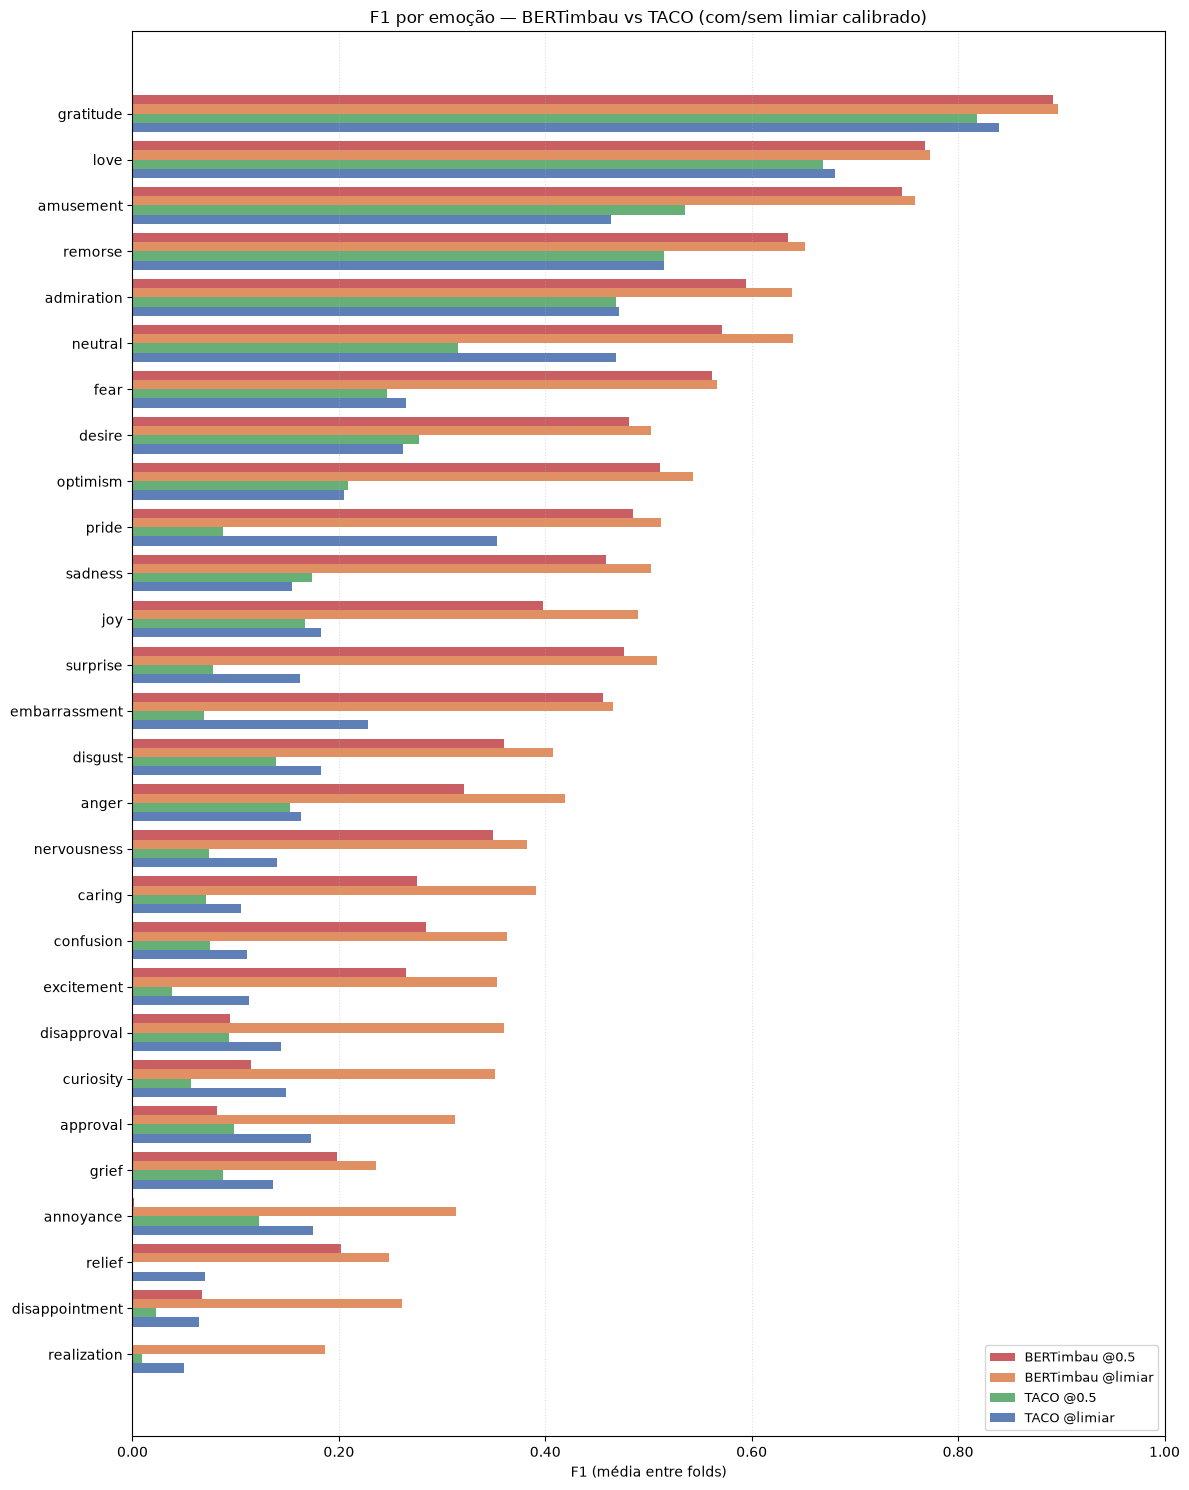

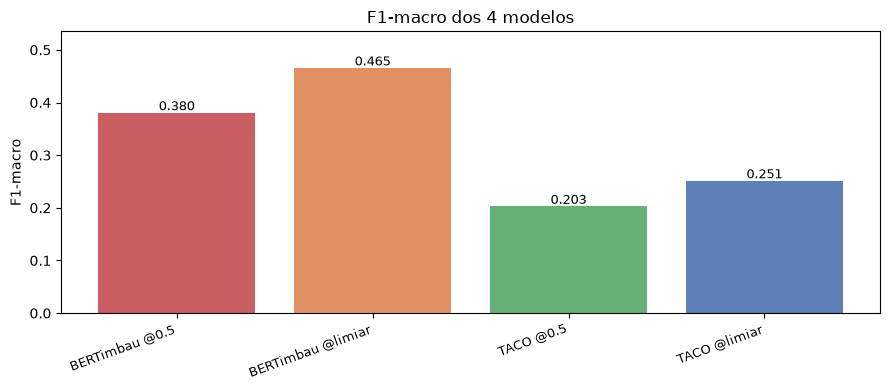

In [17]:
f1_per_label = {
    name: pd.DataFrame([m["f1_per_label"] for m in v]).mean()
    for name, v in model_fold_metrics.items()
}
model_order = list(MODEL_NAMES.values())
df_f1_label = pd.DataFrame(f1_per_label)[model_order]
df_f1_label = df_f1_label.loc[df_f1_label.mean(axis=1).sort_values(ascending=False).index]

colors = {
    "BERTimbau @0.5"   : "#C44E52",
    "BERTimbau @limiar": "#DD8452",
    "TACO @0.5"        : "#55A868",
    "TACO @limiar"     : "#4C72B0",
}

n_emo = df_f1_label.shape[0]
y = np.arange(n_emo)
height = 0.20

fig, ax = plt.subplots(figsize=(12, 15))
for i, name in enumerate(model_order):
    ax.barh(y + i * height, df_f1_label[name].values, height,
            label=name, color=colors[name], alpha=0.9)
ax.set_yticks(y + height * 1.5)
ax.set_yticklabels(df_f1_label.index)
ax.invert_yaxis()
ax.set_xlabel("F1 (média entre folds)")
ax.set_xlim(0, 1)
ax.set_title("F1 por emoção — BERTimbau vs TACO (com/sem limiar calibrado)")
ax.legend(loc="lower right", fontsize=9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="x", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

# resumo: F1-macro dos 4 modelos
fig, ax = plt.subplots(figsize=(9, 4))
macro = ranking.reindex(model_order)
ax.bar(range(len(macro)), macro.values,
       color=[colors[n] for n in macro.index], alpha=0.9)
ax.set_xticks(range(len(macro)))
ax.set_xticklabels(macro.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("F1-macro")
ax.set_ylim(0, max(macro.values) * 1.15)
for i, v in enumerate(macro.values):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
ax.set_title("F1-macro dos 4 modelos")
plt.tight_layout()
plt.show()

## Limiares por emoção e exportação

In [18]:
thr_cols = {}
for key in thresholds_store:
    thr_cols[key] = pd.DataFrame(
        {k: thresholds_store[key][k] for k in thresholds_store[key]}, index=EMOTION_COLS
    ).mean(axis=1)
df_thr = pd.DataFrame(thr_cols)
df_thr["base_rate"] = base_rates.reindex(EMOTION_COLS)
df_thr = df_thr.sort_values("base_rate")

print("===== LIMIAR CALIBRADO POR EMOÇÃO (média entre folds) =====")
display(df_thr.round(4))
for key in thresholds_store:
    tm = df_thr[key].mean()
    print(f"  {key:10s}: limiar médio={tm:.3f} | emoções com limiar < 0.5: "
          f"{int((df_thr[key] < 0.5).sum())}/{N_LABELS}")

# ── exporta resultados (nenhuma imagem é salva) ──
EXPORT_DIR = OUT_BASE / "baseline_taco"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

rows_global = []
for name, d in model_frames.items():
    for fold in d.index:
        rec = {"modelo": name, "outer_fold": fold}
        rec.update({c: d.loc[fold, c] for c in SUMMARY_KEYS})
        rows_global.append(rec)
pd.DataFrame(rows_global).to_csv(EXPORT_DIR / "taco_4models_metrics.csv", index=False)
df_f1_label.to_csv(EXPORT_DIR / "taco_4models_f1_per_label.csv")
df_thr.to_csv(EXPORT_DIR / "taco_thresholds_por_emocao.csv")

summary = {
    "modelos": {k: MODELS[k]["model_name"] for k in MODELS},
    "arquitetura_taco": {
        "views": ["instance-label (BCE-CB sobre h_u.h_e)",
                  "instance-instance (CCL, k-means + InfoNCE)",
                  "label-label (LDL, confusabilidade das colunas)"],
        "alpha": TACO_ALPHA, "beta": TACO_BETA, "temperature": TACO_TEMPERATURE,
        "feat_dim": TACO_FEAT_DIM, "adaptacao": "multi-label, 27 emoções + neutral",
    },
    "estrategia": ("Outer CV (5 folds) + seleção de época por validação interna (anti-vazamento); "
                   "limiar calibrado por emoção nos folds j!=k (OOF)."),
    "n_labels": N_LABELS,
    "grade_limiar": [float(THRESH_GRID.min()), float(THRESH_GRID.max()), int(len(THRESH_GRID))],
    "compressao_checkpoint": COMPRESSION,
    "resultados_4_modelos": {
        name: {
            "f1_macro": f"{d['f1_macro'].mean():.4f} +/- {d['f1_macro'].std():.4f}",
            "f1_micro": f"{d['f1_micro'].mean():.4f}",
            "precision_macro": f"{d['precision_macro'].mean():.4f}",
            "recall_macro": f"{d['recall_macro'].mean():.4f}",
            "avg_precision_macro": f"{d['avg_precision_macro'].mean():.4f}",
            "roc_auc_macro": f"{d['roc_auc_macro'].mean():.4f}",
        } for name, d in model_frames.items()
    },
    "nota_vazamento": (
        "Melhor epoca escolhida por validacao interna (nunca pelo teste). OOF: predicao do fold k "
        "vem de modelo treinado sem k. Limiar calibrado em folds j!=k. Pesos da CB-Loss so do treino."
    ),
    "ressalva": ("Reimplementacao adaptada do TACO (PT-BR, multi-label, 28 classes). NAO comparavel "
                 "ao Macro-F1 do artigo (ingles, single-label, 27 classes)."),
}
with open(EXPORT_DIR / "baseline_taco_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("\nArquivos exportados para", EXPORT_DIR.resolve())
print(json.dumps(summary, indent=2, ensure_ascii=False))

===== LIMIAR CALIBRADO POR EMOÇÃO (média entre folds) =====


,bertimbau,taco,base_rate
grief,0.20,0.15,0.0018
pride,0.35,0.19,0.0026
relief,0.20,0.10,0.0034
nervousness,0.24,0.22,0.0038
embarrassment,0.40,0.30,0.0069
remorse,0.22,0.50,0.0123
fear,0.38,0.44,0.0141
desire,0.25,0.43,0.0148
disgust,0.22,0.42,0.0187
excitement,0.20,0.17,0.0194


  bertimbau : limiar médio=0.245 | emoções com limiar < 0.5: 28/28
  taco      : limiar médio=0.250 | emoções com limiar < 0.5: 25/28

Arquivos exportados para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\baseline_taco
{
  "modelos": {
    "bertimbau": "neuralmind/bert-base-portuguese-cased",
    "taco": "neuralmind/bert-base-portuguese-cased"
  },
  "arquitetura_taco": {
    "views": [
      "instance-label (BCE-CB sobre h_u.h_e)",
      "instance-instance (CCL, k-means + InfoNCE)",
      "label-label (LDL, confusabilidade das colunas)"
    ],
    "alpha": 0.4,
    "beta": 0.4,
    "temperature": 0.5,
    "feat_dim": 128,
    "adaptacao": "multi-label, 27 emoções + neutral"
  },
  "estrategia": "Outer CV (5 folds) + seleção de época por validação interna (anti-vazamento); limiar calibrado por emoção nos folds j!=k (OOF).",
  "n_labels": 28,
  "grade_limiar": [
    0.05,
    0.95,
    19
  ],
  "compressao_checkpoint": "xz",
  "resultados_4_

## Análise de Erros por Emoção — Fusão com Ekman

Para as emoções com F1 mais baixo, investigamos se o modelo as "confunde" dentro do mesmo grupo de
Ekman (ex.: confundir `grief` com `sadness`). Se for esse o caso, **fundir** essas emoções no rótulo
pai de Ekman recupera F1 sem perder informação relevante.

Esta análise é especialmente interessante para o TACO: a visão **rótulo–rótulo (LDL)** existe
justamente para *afastar* rótulos confundíveis. Comparar os grupos que mais se beneficiam da fusão
no BERTimbau simples e no TACO ajuda a ver se as três visões reduziram a confusabilidade entre
emoções semanticamente próximas (`admiration ↔ approval`, `grief ↔ sadness`, etc.).

A célula gera **um arquivo HTML por modelo** com F1 por emoção, grupo de Ekman, matriz de
co-ocorrências preditas e a simulação de F1 após a fusão.

In [19]:
import json

EKMAN_MAP = {
    "anger"  : ["anger", "annoyance", "disapproval"],
    "disgust": ["disgust"],
    "fear"   : ["fear", "nervousness"],
    "joy"    : ["joy", "amusement", "approval", "excitement", "gratitude",
                "love", "optimism", "relief", "pride", "admiration",
                "desire", "caring"],
    "sadness": ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
    "surprise": ["surprise", "realization", "confusion", "curiosity"],
}
EMO_TO_EKMAN = {emo: grp for grp, emos in EKMAN_MAP.items() for emo in emos}

HTML_TEMPLATE = """<!DOCTYPE html>
<html lang="pt-BR">
<head>
<meta charset="UTF-8">
<title>Análise de Erros — Ekman × GoEmotions</title>
<style>
  *{box-sizing:border-box;margin:0;padding:0}
  body{font-family:"Segoe UI",Arial,sans-serif;background:#f5f6fa;color:#222;padding:24px}
  h1{font-size:1.35rem;margin-bottom:4px}
  .subtitle{color:#666;font-size:.9rem;margin-bottom:20px}
  .card{background:#fff;border-radius:8px;box-shadow:0 1px 4px rgba(0,0,0,.1);
        margin-bottom:20px;overflow:hidden}
  .card-header{padding:12px 16px;display:flex;align-items:center;gap:12px;cursor:pointer;
               user-select:none}
  .card-header:hover{background:#fafbff}
  .ekman-badge{display:inline-block;padding:2px 9px;border-radius:12px;font-size:.75rem;
               font-weight:700;color:#fff;white-space:nowrap}
  .card-body{padding:16px;border-top:1px solid #eee;display:none}
  .card.open .card-body{display:block}
  .chevron{margin-left:auto;font-size:1rem;transition:transform .2s}
  .card.open .chevron{transform:rotate(180deg)}
  .emo-row{display:flex;align-items:center;gap:8px;margin-bottom:7px}
  .emo-name{width:130px;font-size:.82rem;white-space:nowrap;overflow:hidden;
             text-overflow:ellipsis}
  .bar-bg{flex:1;background:#e9ecef;border-radius:4px;height:14px;position:relative}
  .bar-fill{height:100%;border-radius:4px;transition:width .3s}
  .bar-val{position:absolute;right:4px;top:0;font-size:.7rem;line-height:14px;color:#444}
  .merge-box{background:#f8f9ff;border:1px solid #dde;border-radius:6px;
             padding:12px 14px;margin-top:14px;font-size:.84rem}
  .merge-box h4{margin-bottom:6px;font-size:.88rem;color:#3a3f8f}
  .delta{font-weight:700}
  .delta.pos{color:#2a7a2a}.delta.neg{color:#c0392b}.delta.neu{color:#888}
  .co-section{margin-top:14px}
  .co-section h4{font-size:.88rem;color:#555;margin-bottom:6px}
  table{border-collapse:collapse;width:100%;font-size:.78rem}
  th,td{border:1px solid #ddd;padding:5px 8px;text-align:center}
  th{background:#f0f0f0;font-weight:600}
  td.row-label{text-align:left;font-weight:600;background:#fafafa}
  .heat0{background:#fff}.heat1{background:#ddeeff}.heat2{background:#99ccee}
  .heat3{background:#4499cc;color:#fff}.heat4{background:#005588;color:#fff}
  .controls{margin-bottom:16px;display:flex;gap:12px;align-items:center;flex-wrap:wrap}
  select,input{padding:5px 8px;border:1px solid #ccc;border-radius:5px;font-size:.85rem}
  label{font-size:.85rem;color:#444}
  .top-f1{margin-bottom:16px}
  .top-f1 h3{font-size:.95rem;margin-bottom:6px;color:#333}
  .worst-table td,.worst-table th{padding:4px 10px}
  .ekman-tag{font-size:.7rem;padding:1px 6px;border-radius:10px;color:#fff;
             display:inline-block;vertical-align:middle;margin-left:4px}
  .model-pill{display:inline-block;padding:2px 10px;border-radius:14px;font-size:.78rem;
              font-weight:600;color:#fff;margin-left:6px}
</style>
</head>
<body>
<h1>Análise de Erros — GoEmotions × Ekman</h1>
<div class="subtitle" id="subtitle"></div>

<div class="controls">
  <label>Ordenar grupos por:
    <select id="sortGroups">
      <option value="f1_mean">F1-médio do grupo (↑)</option>
      <option value="f1_mean_desc">F1-médio do grupo (↓)</option>
      <option value="delta">Ganho de fusão (↑)</option>
      <option value="alpha">Ordem alfabética</option>
    </select>
  </label>
  <label>Pior N emoções:
    <input type="number" id="worstN" value="8" min="2" max="28" style="width:60px">
  </label>
  <button onclick="renderAll()" style="padding:5px 12px;cursor:pointer">Atualizar</button>
</div>

<div class="top-f1">
  <h3>Emoções com menor F1 (modelo OOF)</h3>
  <div id="worstTable"></div>
</div>

<div id="groups"></div>

<script>
const D = __DATA__;
const EKMAN_COLORS = {
  anger:"#e74c3c", disgust:"#8e44ad", fear:"#e67e22",
  joy:"#f1c40f", sadness:"#3498db", surprise:"#1abc9c"
};
function heat(v,max){
  if(max===0)return"heat0";const r=v/max;
  if(r<0.01)return"heat0";if(r<0.25)return"heat1";
  if(r<0.50)return"heat2";if(r<0.75)return"heat3";return"heat4";
}
function ekmanBadge(grp){
  const c=EKMAN_COLORS[grp]||"#888";
  return`<span class="ekman-badge" style="background:${c}">${grp}</span>`;
}
function renderWorstTable(n){
  const entries=Object.entries(D.f1_per_emo).sort((a,b)=>a[1]-b[1]).slice(0,n);
  let html=`<table class="worst-table"><tr><th>#</th><th>Emoção</th><th>Grupo Ekman</th>
    <th>F1</th><th>F1 fundido*</th><th>Δ global**</th></tr>`;
  entries.forEach(([emo,f1],i)=>{
    const grp=D.emo_to_ekman[emo]||"—";
    const c=EKMAN_COLORS[grp]||"#888";
    const mg=D.groups[grp]?D.groups[grp].merge_sim:null;
    const f1m=mg?mg.f1_merged.toFixed(4):"—";
    const dg=mg?mg.delta_global:null;
    const dg_str=dg!=null?(dg>=0?`+${dg.toFixed(4)}`:dg.toFixed(4)):"—";
    const dg_cls=dg!=null?(dg>0.001?"pos":dg<-0.001?"neg":"neu"):"";
    html+=`<tr><td>${i+1}</td><td><strong>${emo}</strong></td>
      <td><span class="ekman-badge" style="background:${c}">${grp}</span></td>
      <td>${f1.toFixed(4)}</td><td>${f1m}</td>
      <td class="delta ${dg_cls}">${dg_str}</td></tr>`;
  });
  html+=`</table>
  <p style="font-size:.75rem;color:#888;margin-top:6px">
  * F1 do label fundido = OR das emoções do mesmo grupo de Ekman.
  ** Δ global = F1-macro com fusão − F1-macro sem fusão (emoções mapeadas, sem neutral).</p>`;
  document.getElementById("worstTable").innerHTML=html;
}
function renderGroup(grp,info){
  const c=EKMAN_COLORS[grp]||"#888";
  const sim=info.merge_sim;
  const delta=sim.delta_global;
  const dCls=delta>0.001?"pos":delta<-0.001?"neg":"neu";
  const dStr=(delta>=0?"+":"")+delta.toFixed(4);
  let bars="";
  Object.entries(info.f1_each).sort((a,b)=>a[1]-b[1]).forEach(([emo,f1])=>{
    const pct=(f1*100).toFixed(1);
    bars+=`<div class="emo-row">
      <div class="emo-name" title="${emo}">${emo}</div>
      <div class="bar-bg">
        <div class="bar-fill" style="width:${pct}%;background:${c}88"></div>
        <span class="bar-val">${f1.toFixed(3)}</span>
      </div></div>`;
  });
  const emos=info.emos;
  let coHdr=`<tr><th>real↓ / pred→</th>`+emos.map(e=>`<th>${e}</th>`).join("")+`</tr>`;
  let coRows="";
  let maxCo=0;
  emos.forEach(a=>emos.forEach(b=>{
    if(a===b)return;
    maxCo=Math.max(maxCo,info.cooccur_pred[`${a}|${b}`]||0);
  }));
  emos.forEach(a=>{
    coRows+=`<tr><td class="row-label">${a}</td>`;
    emos.forEach(b=>{
      if(a===b){coRows+=`<td style="background:#f0f0f0">—</td>`;return;}
      const v=info.cooccur_pred[`${a}|${b}`]||0;
      coRows+=`<td class="${heat(v,maxCo)}">${v}</td>`;
    });
    coRows+=`</tr>`;
  });
  const origList=Object.entries(sim.f1_orig_per_emo)
    .map(([e,f])=>`<span title="${e}">${e}: <b>${f.toFixed(3)}</b></span>`).join(" · ");
  return`
    <div style="font-size:.83rem;color:#555;margin-bottom:10px">
      F1-médio do grupo: <b>${info.f1_mean.toFixed(3)}</b> &nbsp;|&nbsp; ${emos.length} emoções
    </div>
    ${bars}
    <div class="merge-box">
      <h4>Simulação de fusão: OR(${emos.join(", ")}) → <em>${grp}</em></h4>
      <p style="margin-bottom:6px">${origList}</p>
      <p>F1 fundido (label único): <b>${sim.f1_merged.toFixed(4)}</b></p>
      <p>F1-macro global <em>sem</em> fusão: <b>${sim.f1_global_orig.toFixed(4)}</b>
         &nbsp;→&nbsp; <em>com</em> fusão: <b>${sim.f1_global_fused.toFixed(4)}</b>
         &nbsp; Δ = <span class="delta ${dCls}">${dStr}</span></p>
      <p style="font-size:.75rem;color:#888;margin-top:6px">
        Fusão: OR de Y_true e Y_pred nas colunas do grupo. Exclui "neutral" do cálculo.</p>
    </div>
    ${emos.length>1?`
    <div class="co-section">
      <h4>Co-ocorrências preditas dentro do grupo
        <span style="font-size:.75rem;font-weight:400">(linha=real=1 ; coluna=pred=1 ; mais escuro=mais frequente)</span>
      </h4>
      <table>${coHdr}${coRows}</table>
    </div>`:""}`;
}
function sortedGroupKeys(){
  const s=document.getElementById("sortGroups").value;
  const keys=Object.keys(D.groups);
  if(s==="alpha") return keys.sort();
  if(s==="f1_mean_desc") return keys.sort((a,b)=>D.groups[b].f1_mean-D.groups[a].f1_mean);
  if(s==="f1_mean")      return keys.sort((a,b)=>D.groups[a].f1_mean-D.groups[b].f1_mean);
  if(s==="delta") return keys.sort((a,b)=>
      D.groups[b].merge_sim.delta_global-D.groups[a].merge_sim.delta_global);
  return keys;
}
function renderAll(){
  const n=parseInt(document.getElementById("worstN").value)||8;
  renderWorstTable(n);
  const container=document.getElementById("groups");
  container.innerHTML="";
  sortedGroupKeys().forEach(grp=>{
    const info=D.groups[grp];const c=EKMAN_COLORS[grp]||"#888";
    const delta=info.merge_sim.delta_global;
    const dCls=delta>0.001?"pos":delta<-0.001?"neg":"neu";
    const dStr=(delta>=0?"+":"")+delta.toFixed(4);
    const div=document.createElement("div");
    div.className="card";
    div.innerHTML=`
      <div class="card-header" onclick="this.parentElement.classList.toggle('open')">
        ${ekmanBadge(grp)}
        <span style="font-size:.9rem;font-weight:600">${grp.toUpperCase()}</span>
        <span style="font-size:.82rem;color:#666">&nbsp;·&nbsp; F1-médio ${info.f1_mean.toFixed(3)}
          &nbsp;|&nbsp; fusão Δ = <span class="delta ${dCls}">${dStr}</span></span>
        <span class="chevron">▼</span>
      </div>
      <div class="card-body">${renderGroup(grp,info)}</div>`;
    container.appendChild(div);
  });
}
function init(){
  const pill=`<span class="model-pill" style="background:${D.model_color||'#4C72B0'}">${D.model_display}</span>`;
  document.getElementById("subtitle").innerHTML=
    "Modelo: "+D.best_model+pill+" — OOF (predição fora do fold de treino)";
  renderAll();
  const worst=Object.entries(D.groups).sort((a,b)=>a[1].f1_mean-b[1].f1_mean)[0][0];
  document.querySelectorAll(".card").forEach(c=>{
    const lbl=c.querySelector(".card-header span:nth-child(2)");
    if(lbl&&lbl.textContent.trim().toLowerCase()===worst)c.classList.add("open");
  });
}
init();
</script>
</body></html>"""

def cooccurrence_within_group(group_emos, Y_true_all, Y_pred_all):
    idx = [EMOTION_COLS.index(e) for e in group_emos if e in EMOTION_COLS]
    co  = {"true": {}, "pred": {}}
    for i in idx:
        for j in idx:
            if i == j: continue
            a, b = EMOTION_COLS[i], EMOTION_COLS[j]
            co["true"][(a, b)] = int((Y_true_all[:, i] & Y_true_all[:, j]).sum())
            co["pred"][(a, b)] = int((Y_true_all[:, i] & Y_pred_all[:, j]).sum())
    return co

def simulate_merge(group_name, group_emos, Y_true_all, Y_pred_all, f1_best):
    from sklearn.metrics import f1_score as _f1

    in_group  = [e for e in group_emos if e in EMOTION_COLS]
    out_group = [e for e in EMOTION_COLS
                 if e not in set(in_group) and e in EMO_TO_EKMAN]

    idx_in  = [EMOTION_COLS.index(e) for e in in_group]
    idx_out = [EMOTION_COLS.index(e) for e in out_group]

    f1_orig_group = _f1(Y_true_all[:, idx_in], Y_pred_all[:, idx_in],
                        average=None, zero_division=0)

    y_true_merged = Y_true_all[:, idx_in].max(axis=1)
    y_pred_merged = Y_pred_all[:, idx_in].max(axis=1)
    f1_merged = _f1(y_true_merged, y_pred_merged, zero_division=0)

    Y_true_new = np.hstack([Y_true_all[:, idx_out], y_true_merged[:, None]])
    Y_pred_new = np.hstack([Y_pred_all[:, idx_out], y_pred_merged[:, None]])
    f1_global_fused = _f1(Y_true_new, Y_pred_new, average="macro", zero_division=0)

    idx_all = idx_in + idx_out
    f1_global_orig  = _f1(Y_true_all[:, idx_all], Y_pred_all[:, idx_all],
                          average="macro", zero_division=0)

    return {
        "f1_orig_per_emo": {e: float(round(f, 4)) for e, f in zip(in_group, f1_orig_group)},
        "f1_merged"      : round(float(f1_merged), 4),
        "f1_global_orig" : round(float(f1_global_orig), 4),
        "f1_global_fused": round(float(f1_global_fused), 4),
        "delta_global"   : round(float(f1_global_fused - f1_global_orig), 4),
    }

MODEL_COLORS = {"bertimbau": "#DD8452", "taco": "#4C72B0"}

def build_payload_and_html(model_key, model_display, best_model_name,
                           Y_true_all, Y_pred_all, f1_best):
    payload = {
        "model_key"    : model_key,
        "model_display": model_display,
        "model_color"  : MODEL_COLORS.get(model_key, "#4C72B0"),
        "best_model"   : best_model_name,
        "ekman_map"    : EKMAN_MAP,
        "emo_to_ekman" : EMO_TO_EKMAN,
        "f1_per_emo"   : {e: round(float(f1_best[e]), 4) for e in EMOTION_COLS},
        "groups"       : {},
    }
    for grp, emos in EKMAN_MAP.items():
        in_vocab = [e for e in emos if e in EMOTION_COLS]
        co  = cooccurrence_within_group(in_vocab, Y_true_all, Y_pred_all)
        sim = simulate_merge(grp, in_vocab, Y_true_all, Y_pred_all, f1_best)
        payload["groups"][grp] = {
            "emos"        : in_vocab,
            "f1_each"     : {e: round(float(f1_best[e]), 4) for e in in_vocab},
            "f1_mean"     : round(float(np.mean([f1_best[e] for e in in_vocab])), 4),
            "cooccur"     : {f"{a}|{b}": v for (a, b), v in co["true"].items()},
            "cooccur_pred": {f"{a}|{b}": v for (a, b), v in co["pred"].items()},
            "merge_sim"   : sim,
        }
    html = HTML_TEMPLATE.replace("__DATA__", json.dumps(payload, ensure_ascii=False))
    return payload, html

print("=" * 65)
print("  ANÁLISE DE ERROS — FUSÃO COM EKMAN")
print("=" * 65)

for model_key, cfg in MODELS.items():
    model_display    = cfg["display"]
    best_model_name  = MODEL_NAMES[(model_key, "tuned")]   # @limiar
    P_folds_model    = PROBA[model_key]

    thr_mean = np.vstack(
        [thresholds_store[model_key][k] for k in range(1, N_OUTER_FOLDS + 1)]
    ).mean(axis=0)

    Y_true_all = np.vstack([Y_folds[k]       for k in range(1, N_OUTER_FOLDS + 1)])
    P_all      = np.vstack([P_folds_model[k] for k in range(1, N_OUTER_FOLDS + 1)])
    Y_pred_all = (P_all >= thr_mean[None, :]).astype(int)

    f1_best = pd.DataFrame(
        [m["f1_per_label"] for m in model_fold_metrics[best_model_name]]
    ).mean().reindex(EMOTION_COLS)

    payload, html_str = build_payload_and_html(
        model_key, model_display, best_model_name,
        Y_true_all, Y_pred_all, f1_best,
    )

    out_path = EXPORT_DIR / f"ekman_error_analysis_{model_key}.html"
    out_path.write_text(html_str, encoding="utf-8")
    print(f"\n✓ {model_display}: HTML salvo em {out_path.resolve()}")

    print(f"\n  {'Grupo':<10} {'F1-médio':>9} {'F1-fundido':>11} {'Δ-global':>10}  emoções")
    rows_ekman = sorted(
        payload["groups"].items(),
        key=lambda kv: kv[1]["merge_sim"]["delta_global"],
        reverse=True,
    )
    for grp, g in rows_ekman:
        s    = g["merge_sim"]
        sign = "+" if s["delta_global"] >= 0 else ""
        print(f"  {grp:<10} {g['f1_mean']:>9.4f} {s['f1_merged']:>11.4f} "
              f"  {sign}{s['delta_global']:>8.4f}  {', '.join(g['emos'])}")

print(f"\n✓ Arquivos HTML gravados em {EXPORT_DIR.resolve()}")

  ANÁLISE DE ERROS — FUSÃO COM EKMAN

✓ BERTimbau: HTML salvo em C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\baseline_taco\ekman_error_analysis_bertimbau.html

  Grupo       F1-médio  F1-fundido   Δ-global  emoções
  surprise      0.3522      0.4640   +  0.0183  surprise, realization, confusion, curiosity
  anger         0.3640      0.4971   +  0.0131  anger, annoyance, disapproval
  sadness       0.4234      0.5673   +  0.0112  sadness, disappointment, embarrassment, grief, remorse
  fear          0.4742      0.5782   +  0.0027  fear, nervousness
  disgust       0.4075      0.4152   + -0.0000  disgust
  joy           0.5349      0.7842    -0.0354  joy, amusement, approval, excitement, gratitude, love, optimism, relief, pride, admiration, desire, caring

✓ TACO: HTML salvo em C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\baseline_taco\ekman_error_analysis_taco.html

  Grupo       F1-médio  F1-fund